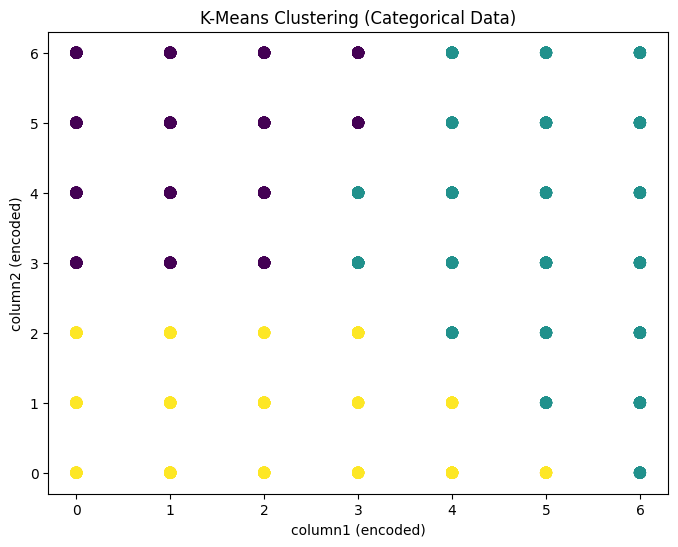

   user_id  movie_id  movie_name  genre  timestamp  watched_duration_pct  \
0      758       890          19      5         76                 20.02   
1       30       140          31      4        952                 64.18   
2      461       352         796      1        538                 96.15   
3      130       847         357      6        639                 66.58   
4       20       910          81      3        578                 35.02   

   liked  disliked  watch_later  shared  ...  user_rating  age_group  \
0  False     False        False   False  ...          NaN          0   
1  False     False        False   False  ...          NaN          1   
2   True     False         True    True  ...          3.9          4   
3  False     False        False   False  ...          NaN          0   
4  False     False        False   False  ...          NaN          4   

   safety_flag  data_source  mood  search_query  search_keywords  session_id  \
0         True            0   

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("data.csv")

# Make a copy to avoid overwriting original
df_encoded = df.copy()

# Encode all categorical columns
label_encoders = {}

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':   # if column is categorical
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = le

# Select two features for visualization
X = df_encoded[['genre', 'mood']]   # change column names!

# Apply K-Means (no scaling)
kmeans = KMeans(n_clusters=3, random_state=42)
df_encoded['cluster'] = kmeans.fit_predict(X)

# Visualization
plt.figure(figsize=(8,6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=df_encoded['cluster'], s=60)

plt.xlabel('column1 (encoded)')
plt.ylabel('column2 (encoded)')
plt.title('K-Means Clustering (Categorical Data)')
plt.show()

# Show clusters
print(df_encoded.head())

In [2]:
print("hello")

hello


In [2]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load Data
# -------------------------------
df = pd.read_csv("data.csv")

# -------------------------------
# 2. Select Required Columns
# -------------------------------
features = df[["genre", "mood", "tags", "user_rating"]]

# -------------------------------
# 3. Handle missing values
# -------------------------------
features["user_rating"] = features["user_rating"].fillna(features["user_rating"].mean())
features["tags"] = features["tags"].fillna(0)
features["genre"] = features["genre"].fillna("Unknown")
features["mood"] = features["mood"].fillna("Unknown")

# -------------------------------
# 4. One-Hot Encode genre & mood
# -------------------------------
ohe = OneHotEncoder(sparse_output=False)

encoded = ohe.fit_transform(features[["genre", "mood"]])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(["genre", "mood"]))

# -------------------------------
# 5. Combine numeric features
# -------------------------------
final_df = pd.concat([
    encoded_df,
    features[["tags", "user_rating"]].reset_index(drop=True)
], axis=1)

# -------------------------------
# 6. Apply K-Means
# -------------------------------
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(final_df)

df["cluster"] = clusters   # store cluster labels in original df

# -------------------------------
# 7. Visualize using PCA (2D)
# -------------------------------
pca = PCA(n_components=2)
pca_result = pca.fit_transform(final_df)

plt.figure(figsize=(10,6))
plt.scatter(pca_result[:,0], pca_result[:,1], c=clusters, cmap='viridis')
plt.title("K-Means Clusters (Visualized with PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster Group")
plt.show()


C:\Users\abhay\AppData\Local\Temp\ipykernel_19476\2122195891.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["user_rating"] = features["user_rating"].fillna(features["user_rating"].mean())
C:\Users\abhay\AppData\Local\Temp\ipykernel_19476\2122195891.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["tags"] = features["tags"].fillna(0)
C:\Users\abhay\AppData\Local\Temp\ipykernel_19476\2122195891.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

ValueError: could not convert string to float: "['Horror', 'mysterious']"

C:\Users\abhay\AppData\Local\Temp\ipykernel_19476\3349158336.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['user_rating'].fillna(df['user_rating'].mean(), inplace=True)
C:\Users\abhay\AppData\Local\Temp\ipykernel_19476\3349158336.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


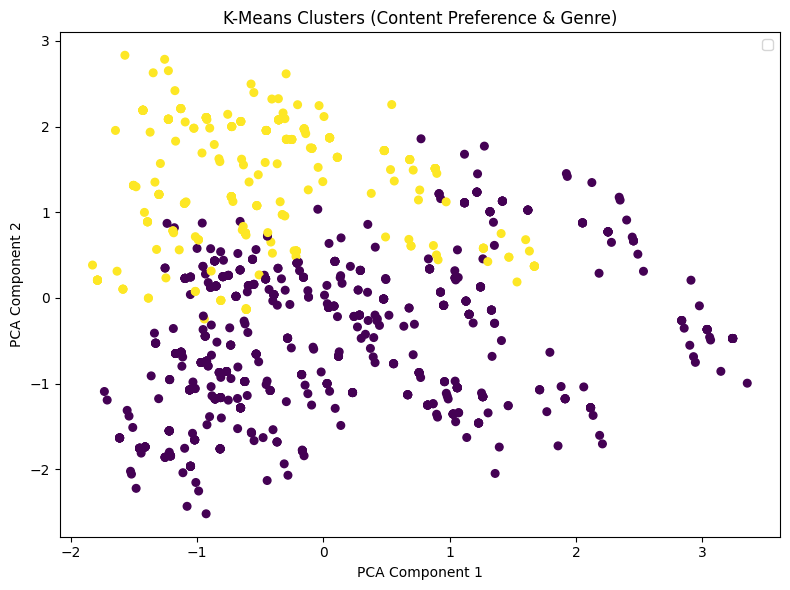

In [92]:
import pandas as pd
import numpy as np
import ast
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Load dataset
df = pd.read_csv("data.csv")   # change path if needed


# 2. One-hot encode 'genre' and 'mood'
genre_dummies = pd.get_dummies(df['genre'], prefix='genre')
mood_dummies = pd.get_dummies(df['mood'], prefix='mood')

# 3. Process 'tags' -> tag_count (number of tags per movie)
def count_tags(x):
    if pd.isna(x):
        return 0
    try:
        tags_list = ast.literal_eval(x)   # convert string "['a','b']" -> ['a','b']
        return len(tags_list)
    except Exception:
        return 0

df['tag_count'] = df['tags'].apply(count_tags)

# 4. Handle user_rating (fill missing values with mean rating)
df['user_rating'] = pd.to_numeric(df['user_rating'], errors='coerce')
df['user_rating'].fillna(df['user_rating'].mean(), inplace=True)

# 5. Build final feature matrix X
X = pd.concat([genre_dummies, mood_dummies, df[['user_rating', 'tag_count']]], axis=1)

X = X.dropna()
# 6. Scale features (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Apply K-Means clustering
k = 4   # number of clusters (you can change this)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Save cluster labels back to original dataframe
df['cluster'] = clusters

# 8. Reduce dimensions to 2D for plotting using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 9. Plot the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:,0], X_pca[:, 1], c = clusters, s = 30)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters (Content Preference & Genre)")
plt.legend()
plt.tight_layout()
plt.show()


In [93]:
from sklearn.compose import ColumnTransformer
preprocessing = ColumnTransformer(
    transformers = [
        ("cat", OneHotEncoder(drop = "first"), cat_columns),
        ("num", StandardScaler(), numeric_columns)
    ]
)
X = df[columns]
X_processesed = preprocessing.fit_transform(X)


kmeans = KMeans(n_clusters = 3, random_state = 42)
clusters = kmeans.fit_predict(X_processesed)

df["cluster"] = clusters
print(df.head(10))
# pca = PCA(n_components = 2)
# X_newdf = pca.fit_transform(X_processesed)

# # Plot
# plt.figure(figsize=(8,8))
# plt.scatter(X_newdf[:, 0], X_newdf[:, 1])
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.title("PCA Scatter Plot")

# plt.show()

NameError: name 'cat_columns' is not defined

In [29]:
df = pd.read_csv("data.csv")
print(df.columns)

Index(['user_id', 'movie_id', 'movie_name', 'genre', 'timestamp',
       'watched_duration_pct', 'liked', 'disliked', 'watch_later', 'shared',
       're_watched', 'watched_full', 'device_type', 'transaction_type',
       'amount_paid', 'country', 'language', 'user_rating', 'age_group',
       'safety_flag', 'data_source', 'mood', 'search_query', 'search_keywords',
       'session_id', 'tags'],
      dtype='object')


In [33]:
map_ = {True: 1, False: 0, "NAN": 0, "NONE": 0}
columns = ["liked","disliked", "watch_later", "shared", "re_watched"]
for col in columns:
    df[col] = df[col].map(map_)


In [34]:
map_ = {"purchase": 2, "rental": 1, "subscription": 0}
df["transaction_type"] = df["transaction_type"].map(map_)

In [35]:
print(df["transaction_type"].head(5))

0    2.0
1    1.0
2    0.0
3    0.0
4    2.0
Name: transaction_type, dtype: float64


In [36]:
df["amount_paid"].dtype

dtype('float64')

In [142]:
pca = PCA(n_components = 2)
x = pca.fit_transform(X)
df["Cluster"] = clusters

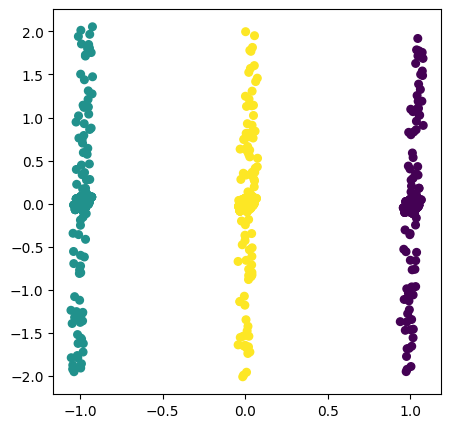

In [143]:
plt.figure(figsize = (5,5))
plt.scatter(x[:])